# U1 VDS 증폭 회로 검증

## 시험 목적
MOSFET의 VDS를 대신하는 DC 입력 전압을 이용해,
U1 회로가 목표 이득 2배로 동작하는지 확인한다.

## 시험 조건
- 증폭기 전원: 5 V / GND
- 소스 측 입력: GND
- 목표 전압 이득: 2배
- 시험 입력: 0.04 V, 0.15 V, 0.30 V
- OP-Amp 모델: 회로 구성 후 기록
- 저항값: 회로 구성 후 기록

In [8]:
import pandas as pd

df_cases = pd.read_csv("../data/processed/mosfet_test_cases.csv")

df_cases[["I_true (A)", "Tc (°C)", "Tj (°C)", "VDS (V)"]]

,I_true (A),Tc (°C),Tj (°C),VDS (V)
0,25,25,25.391946,0.037328
1,25,50,50.444652,0.042348
2,25,75,75.502747,0.047881
3,25,100,100.571244,0.054404
4,25,125,125.642524,0.061193
5,25,150,150.721827,0.068745
6,50,25,26.577752,0.075131
7,50,50,51.791048,0.085288
8,50,75,77.027639,0.096554
9,50,100,102.304631,0.109745


In [9]:
vds_min = df_cases["VDS (V)"].min()
vds_max = df_cases["VDS (V)"].max()

print("최소 VDS:", vds_min, "V")
print("최대 VDS:", vds_max, "V")

최소 VDS: 0.0373283892725 V
최대 VDS: 0.2905990056883645 V


In [10]:
df_u1 = pd.DataFrame({
    "Input (V)": [0.04, 0.15, 0.30]
})

gain_u1 = 2

df_u1["Expected output (V)"] = df_u1["Input (V)"] * gain_u1

df_u1

,Input (V),Expected output (V)
0,0.04,0.08
1,0.15,0.30
2,0.30,0.60


In [11]:
df_u1["LTspice output (V)"] = [
    0.0800074,
    0.300007,
    0.600006
]

df_u1

,Input (V),Expected output (V),LTspice output (V)
0,0.04,0.08,0.080007
1,0.15,0.30,0.300007
2,0.30,0.60,0.600006


In [12]:
df_u1["Actual gain"] = (df_u1["LTspice output (V)"]
                        /df_u1["Input (V)"])
df_u1["Error(%)"] = ((df_u1["LTspice output (V)"]-df_u1["Expected output (V)"])
                     /df_u1["Expected output (V)"]*100)
df_u1

,Input (V),Expected output (V),LTspice output (V),Actual gain,Error(%)
0,0.04,0.08,0.080007,2.000185,0.009250
1,0.15,0.30,0.300007,2.000047,0.002333
2,0.30,0.60,0.600006,2.000020,0.001000


입력 0.04·0.15·0.30 V에서 U1 출력은 목표 이득 2배에 가깝게 나타났다. 예상 출력 대비 최대 오차는 약 0.00925%로, 현재 시뮬레이션 조건에서 기본 증폭 동작을 확인했다. 사용한 OP-Amp 모델의 상세 설정은 추가 확인이 필요하다.

In [13]:
df_u1.to_csv(
    "../results/tables/u1_dc_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

In [14]:
df_u1_cases = df_cases[
    ["I_true (A)", "Tc (°C)", "Tj (°C)", "VDS (V)"]
].copy()

df_u1_cases["Expected U1 output (V)"] = (
    df_u1_cases["VDS (V)"] * gain_u1
)

df_u1_cases

,I_true (A),Tc (°C),Tj (°C),VDS (V),Expected U1 output (V)
0,25,25,25.391946,0.037328,0.074657
1,25,50,50.444652,0.042348,0.084696
2,25,75,75.502747,0.047881,0.095761
3,25,100,100.571244,0.054404,0.108808
4,25,125,125.642524,0.061193,0.122386
5,25,150,150.721827,0.068745,0.137491
6,50,25,26.577752,0.075131,0.150262
7,50,50,51.791048,0.085288,0.170576
8,50,75,77.027639,0.096554,0.193109
9,50,100,102.304631,0.109745,0.219489


In [16]:
df_u1_result = pd.read_csv(
    "../data/processed/u1_24case_outputs.csv",
    encoding="utf-8-sig"
)

print(df_u1_result.columns.tolist())
print(df_u1_result.shape)

df_u1_result.head()

['I_true (A)', 'Tc (°C)', 'VDS (V)', 'U1 output (V)']
(24, 4)


,I_true (A),Tc (°C),VDS (V),U1 output (V)
0,25,25,0.037328,0.074656
1,25,50,0.042348,0.084696
2,25,75,0.047881,0.095762
3,25,100,0.054404,0.108808
4,25,125,0.061193,0.122386


In [17]:
df_u1_compare = df_u1_result.copy()

df_u1_compare["Expected output (V)"] = (
    df_u1_compare["VDS (V)"] * 2
)

df_u1_compare["Actual gain"] = (
    df_u1_compare["U1 output (V)"] / df_u1_compare["VDS (V)"]
)

df_u1_compare["Gain error (%)"] = (
    (
        df_u1_compare["U1 output (V)"]
        - df_u1_compare["Expected output (V)"]
    )
    / df_u1_compare["Expected output (V)"]
    * 100
)

df_u1_compare

,I_true (A),Tc (°C),VDS (V),U1 output (V),Expected output (V),Actual gain,Gain error (%)
0,25,25,0.037328,0.074656,0.074656,2.0,0.0
1,25,50,0.042348,0.084696,0.084696,2.0,0.0
2,25,75,0.047881,0.095762,0.095762,2.0,0.0
3,25,100,0.054404,0.108808,0.108808,2.0,0.0
4,25,125,0.061193,0.122386,0.122386,2.0,0.0
5,25,150,0.068745,0.137490,0.137490,2.0,0.0
6,50,25,0.075131,0.150262,0.150262,2.0,0.0
7,50,50,0.085288,0.170576,0.170576,2.0,0.0
8,50,75,0.096554,0.193108,0.193108,2.0,0.0
9,50,100,0.109745,0.219490,0.219490,2.0,0.0


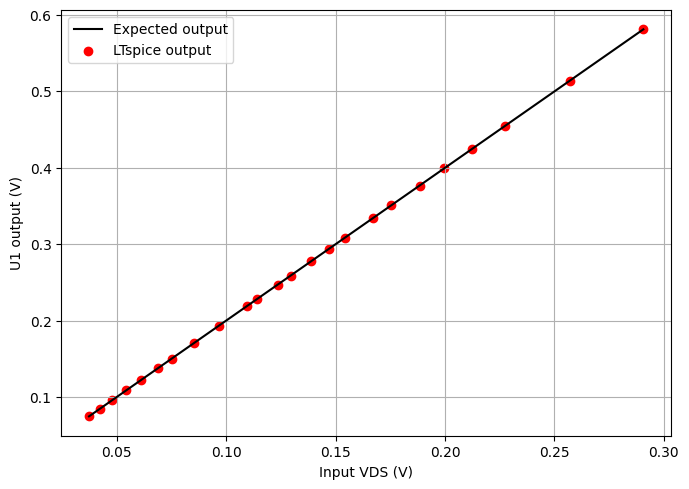

In [18]:
import matplotlib.pyplot as plt

df_plot = df_u1_compare.sort_values("VDS (V)")

plt.figure(figsize=(7, 5))

plt.plot(
    df_plot["VDS (V)"],
    df_plot["Expected output (V)"],
    label="Expected output",
    color="black"
)

plt.scatter(
    df_plot["VDS (V)"],
    df_plot["U1 output (V)"],
    label="LTspice output",
    color="red"
)

plt.xlabel("Input VDS (V)")
plt.ylabel("U1 output (V)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("../results/figures/u1_24case_validation.png", dpi=300)
plt.show()

In [19]:
df_u1_compare.to_csv(
    "../results/tables/u1_24case_validation.csv",
    index=False,
    encoding="utf-8-sig"
)

### 24개 조건의 U1 검증 결과

24개 입력 조건에서 저장된 U1 출력은 예상 출력인 입력 VDS의 2배와 일치했다.
CSV에 기록된 자릿수 기준으로 증폭 이득 오차는 0%였다.
이는 현재 시뮬레이션 모델과 저장 정밀도에서의 결과이며,
실제 회로 오차가 완전히 없음을 의미하지 않는다.

이번 시험은 U1의 증폭 동작을 확인한 것으로,
온도보상 및 Calibration의 효과는 별도로 평가한다.